In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_classif
from sklearn.decomposition import PCA

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import StackingClassifier

from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,ConfusionMatrixDisplay,f1_score


In [2]:
df=pd.read_csv('Heart_Disease_Prediction.csv')
df.head()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,Presence
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,Absence
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,Presence
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,Absence
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,Absence


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      270 non-null    int64  
 1   Sex                      270 non-null    int64  
 2   Chest pain type          270 non-null    int64  
 3   BP                       270 non-null    int64  
 4   Cholesterol              270 non-null    int64  
 5   FBS over 120             270 non-null    int64  
 6   EKG results              270 non-null    int64  
 7   Max HR                   270 non-null    int64  
 8   Exercise angina          270 non-null    int64  
 9   ST depression            270 non-null    float64
 10  Slope of ST              270 non-null    int64  
 11  Number of vessels fluro  270 non-null    int64  
 12  Thallium                 270 non-null    int64  
 13  Heart Disease            270 non-null    str    
dtypes: float64(1), int64(12), str(1)
memo

In [4]:
df.describe()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
count,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.00000,270.000000,270.000000,270.000000
mean,54.433333,0.677778,3.174074,131.344444,249.659259,0.148148,1.022222,149.677778,0.329630,1.05000,1.585185,0.670370,4.696296
std,9.109067,0.468195,0.950090,17.861608,51.686237,0.355906,0.997891,23.165717,0.470952,1.14521,0.614390,0.943896,1.940659
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.00000,1.000000,0.000000,3.000000
25%,48.000000,0.000000,3.000000,120.000000,213.000000,0.000000,0.000000,133.000000,0.000000,0.00000,1.000000,0.000000,3.000000
50%,55.000000,1.000000,3.000000,130.000000,245.000000,0.000000,2.000000,153.500000,0.000000,0.80000,2.000000,0.000000,3.000000
75%,61.000000,1.000000,4.000000,140.000000,280.000000,0.000000,2.000000,166.000000,1.000000,1.60000,2.000000,1.000000,7.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.20000,3.000000,3.000000,7.000000


In [5]:
df.isnull().mean()*100

Age                        0.0
Sex                        0.0
Chest pain type            0.0
BP                         0.0
Cholesterol                0.0
FBS over 120               0.0
EKG results                0.0
Max HR                     0.0
Exercise angina            0.0
ST depression              0.0
Slope of ST                0.0
Number of vessels fluro    0.0
Thallium                   0.0
Heart Disease              0.0
dtype: float64

In [6]:
df.duplicated().sum()

np.int64(0)

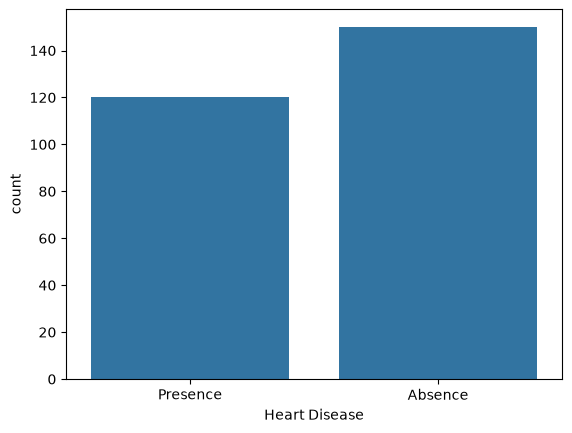

In [7]:
sns.countplot(data=df, x="Heart Disease")
plt.show()

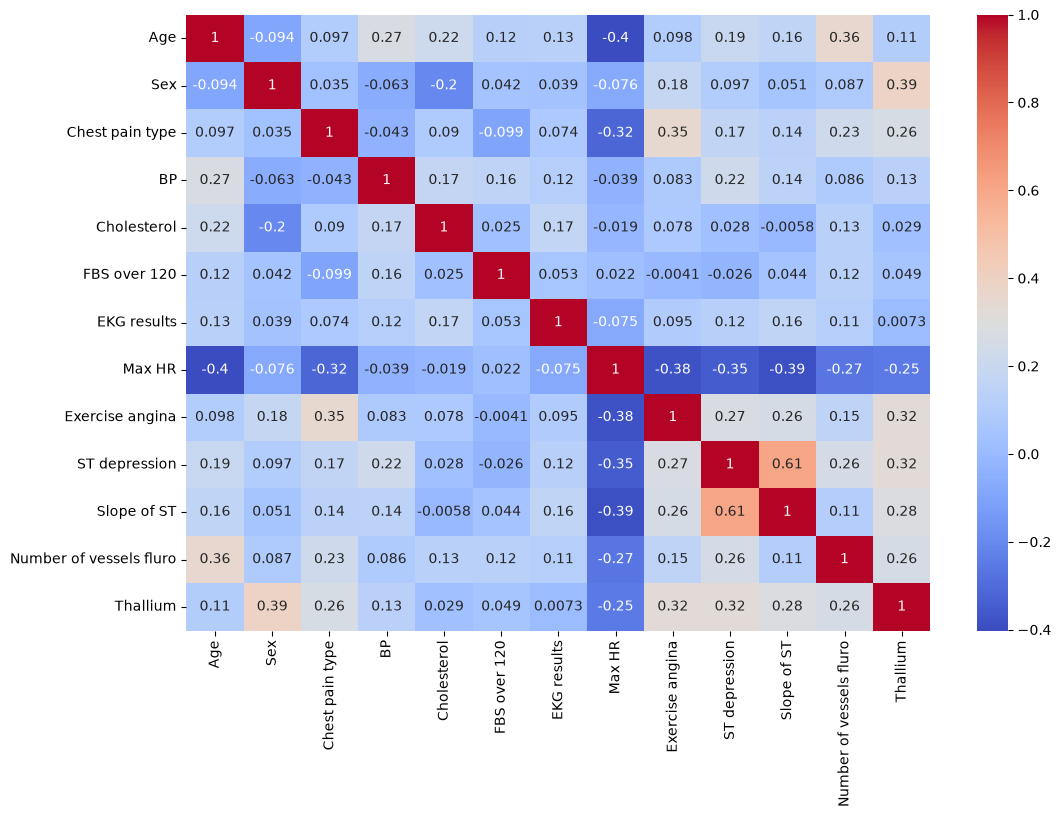

In [8]:
plt.figure(figsize=(12,8))
sns.heatmap(df.drop("Heart Disease",axis=1).corr(),
            annot=True,
            cmap="coolwarm")
plt.show()

## **Target Encoding**

In [9]:
df["Heart Disease"] = df["Heart Disease"].map({"Presence":1, "Absence":0})

In [10]:
X = df.drop("Heart Disease",axis=1)
y = df["Heart Disease"]

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y )
#stratify=y to balance class pprecentage

In [11]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [12]:
mi = mutual_info_classif( X_train_scaled, y_train, random_state=42)
mi_scores = pd.Series(mi,index=X.columns)
mi_scores.sort_values(ascending=False)

Number of vessels fluro    0.116481
Slope of ST                0.110427
Exercise angina            0.106146
Chest pain type            0.104160
ST depression              0.098828
Max HR                     0.070641
Cholesterol                0.063530
Thallium                   0.060804
FBS over 120               0.050480
Sex                        0.029161
BP                         0.024094
Age                        0.000000
EKG results                0.000000
dtype: float64

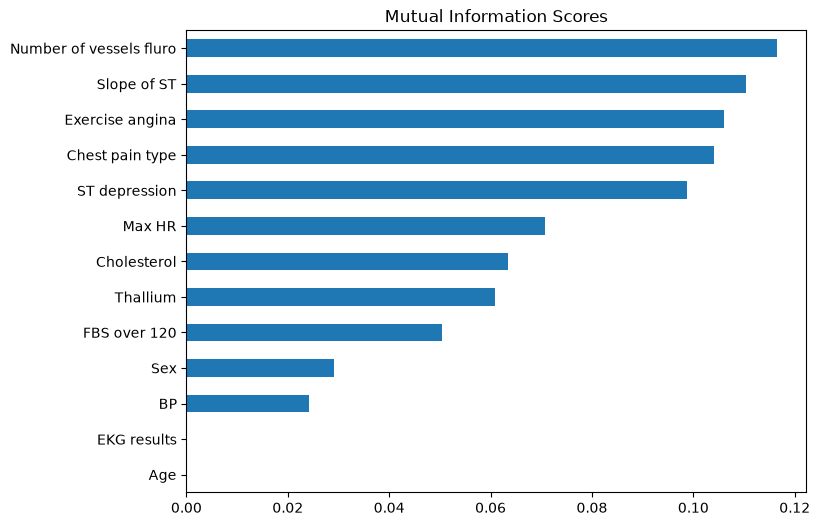

In [13]:
plt.figure(figsize=(8,6))
mi_scores.sort_values().plot.barh()
plt.title("Mutual Information Scores")
plt.show()

In [14]:
selected_features = mi_scores.sort_values(ascending=False).head(10).index
selected_features

Index(['Number of vessels fluro', 'Slope of ST', 'Exercise angina',
       'Chest pain type', 'ST depression', 'Max HR', 'Cholesterol', 'Thallium',
       'FBS over 120', 'Sex'],
      dtype='str')

In [15]:
#the selected data
X_train_selected = pd.DataFrame( X_train_scaled, columns=X.columns)[selected_features]
X_test_selected = pd.DataFrame( X_test_scaled, columns=X.columns)[selected_features]

In [16]:
pca = PCA(n_components=0.9)

X_train_pca = pca.fit_transform(X_train_selected)
X_test_pca = pca.transform(X_test_selected)

print(pca.n_components_)
print(pca.explained_variance_ratio_)

8
[0.28017985 0.12709192 0.11327951 0.10435384 0.08697643 0.08241835
 0.06494459 0.05672531]


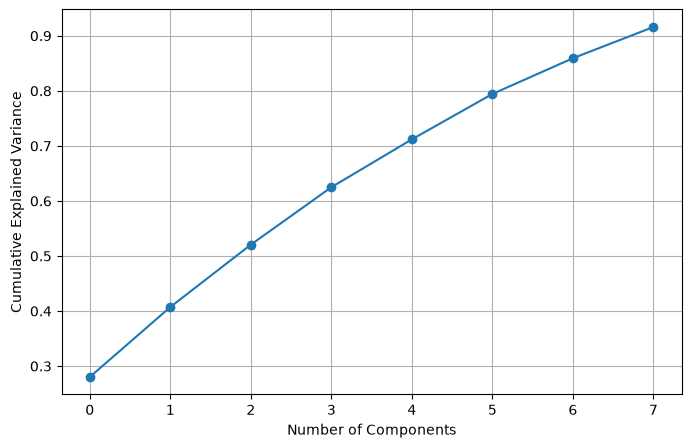

In [17]:
plt.figure(figsize=(8,5))
plt.plot( np.cumsum(pca.explained_variance_ratio_),  marker="o")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.grid()
plt.show()

In [18]:
lr = LogisticRegression(max_iter=1000)
knn = KNeighborsClassifier(n_neighbors=5)
dt = DecisionTreeClassifier(random_state=42)

models = {
    "Logistic Regression":lr,
    "KNN":knn,
    "Decision Tree":dt
}
results = []

for name,model in models.items():

    model.fit(X_train_pca,y_train)
    pred = model.predict(X_test_pca)
    acc = accuracy_score(y_test, pred)
    f1score=f1_score(y_test,pred)
    results.append([name,acc,f1score])
    print(name)
    print(classification_report(y_test,pred))
    
    estimators = [
    ("lr",lr),
    ("knn",knn),
    ("dt",dt)
]

Logistic Regression
              precision    recall  f1-score   support

           0       0.89      0.83      0.86        30
           1       0.81      0.88      0.84        24

    accuracy                           0.85        54
   macro avg       0.85      0.85      0.85        54
weighted avg       0.86      0.85      0.85        54

KNN
              precision    recall  f1-score   support

           0       0.86      0.80      0.83        30
           1       0.77      0.83      0.80        24

    accuracy                           0.81        54
   macro avg       0.81      0.82      0.81        54
weighted avg       0.82      0.81      0.82        54

Decision Tree
              precision    recall  f1-score   support

           0       0.82      0.77      0.79        30
           1       0.73      0.79      0.76        24

    accuracy                           0.78        54
   macro avg       0.78      0.78      0.78        54
weighted avg       0.78      0.78   

In [19]:
stack = StackingClassifier(estimators=estimators,final_estimator=LogisticRegression(),cv=5)
stack.fit(  X_train_pca, y_train)
stack_pred = stack.predict(X_test_pca)

In [20]:
print(classification_report( y_test, stack_pred))

              precision    recall  f1-score   support

           0       0.89      0.83      0.86        30
           1       0.81      0.88      0.84        24

    accuracy                           0.85        54
   macro avg       0.85      0.85      0.85        54
weighted avg       0.86      0.85      0.85        54



In [21]:
accu=accuracy_score( y_test, stack_pred)
f1=f1_score( y_test, stack_pred)
print(accu)
print(f1)

0.8518518518518519
0.84


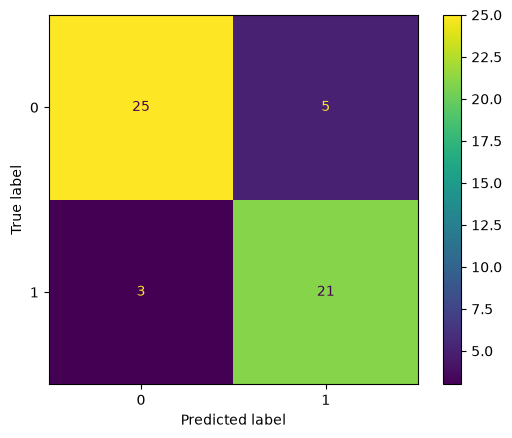

In [22]:
cm = confusion_matrix(y_test, stack_pred)
ConfusionMatrixDisplay( confusion_matrix=cm).plot()
plt.show()

In [23]:
results.append(["Stacking",accuracy_score(y_test,stack_pred),f1_score(y_test,stack_pred)])
comparison = pd.DataFrame( results, columns=[ "Model", "Accuracy","F1 Score" ])
comparison

,Model,Accuracy,F1 Score
0,Logistic Regression,0.851852,0.84
1,KNN,0.814815,0.80
2,Decision Tree,0.777778,0.76
3,Stacking,0.851852,0.84


The Logistic Regression model achieved the highest performance with an Accuracy of 85.19% and an F1-score of 0.84. The Stacking Classifier achieved the same performance, indicating that combining Logistic Regression, KNN, and Decision Tree did not provide additional predictive power for this dataset. This suggests that Logistic Regression alone is sufficient to capture the underlying patterns in the heart disease data.